# Empirical analysis

**Yueying Sun**

April 2026

In this notebook, we use Flow of Funds data to test our mandate model. We download all quarterly data (Z.1 Statistical Release) from Federal Reserve (link: https://www.federalreserve.gov/datadownload/Choose.aspx?rel=z1) and access the data we need by the series number.

## Preparation

First, we import all modules that we need and initialize the datapath, where we put the data downloaded from FoF. In particular, we use 'xml.etree.ElementTree' to get access to the data in xml file and we use the function 'minimize' from the modules 'scipy.optimize' to estimate the optimal parameter.

In [1]:
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn
seaborn.set()

from scipy.optimize import minimize

datapath = './FRB_z1/'

We now choose to access the data through their series number. 

To test our mandate model, we assume that the bond value is the sum of US treasury and the corporate bond, and the equity value is the corporate equity.

Series identifiers:

### Table L210 US Treasury

All sectors; Treasury securities; asset: FL893061105.Q

Rest of the world; Treasury securities; asset: LM263061105.Q

### Table L213 Corporate & Foreign Bonds

All sectors; corporate and foreign bonds; asset: FL893063005.Q

Rest of the world; corporate bonds; asset: LM263063005.Q

### Table L224 Corporate Equities
All sectors; corporate equities; asset: LM893064105.Q

Rest of the world; U.S. corporate equities; asset: LM263064105.Q

In [2]:
SERIES_NAME_LIST = ['FL893061105.Q', 'LM263061105.Q', 'FL893063005.Q', 'LM263063005.Q', 'LM893064105.Q', 'LM263064105.Q']

In [3]:
tree = ET.parse(datapath + 'Z1_data.xml') 
root = tree.getroot()

In [4]:
namespace = {
    'kf': 'http://www.federalreserve.gov/structure/compact/Z1_Z1',
    'frb': 'http://www.federalreserve.gov/structure/compact/common'
}

data_lists = []
time_lists = []

for name in SERIES_NAME_LIST:
    new_list_data = []
    new_list_time = []
    for series in root.findall('.//kf:Series', namespaces=namespace):
        series_name = series.get('SERIES_NAME')
        if series_name == name:
            observations = series.findall('.//frb:Obs', namespaces=namespace)
            
            # Extract OBS_VALUE and TIME_PERIOD and store them in arrays
            for obs in observations:
                obs_value = obs.get('OBS_VALUE')
                time_period = obs.get('TIME_PERIOD')
                new_list_data.append(obs_value)
                new_list_time.append(time_period)
    data_lists.append(new_list_data)
    time_lists.append(new_list_time)

In [5]:
# Checking that all the time lists are the same"
all_identical = True
for list_cand in time_lists:
    all_identical &= (list_cand == time_lists[0])
    
assert all_identical

In [6]:
df = pd.DataFrame(map(list, zip(*data_lists)), index=pd.to_datetime(time_lists[0])).apply(pd.to_numeric)
df.columns = ['UST_All', 'UST_RoW', 'CB_All', 'CB_RoW', 'CE_All', 'CE_RoW']
df = df.mask(df < 0).ffill()    #as before 1960, there are only annual data and others are coded as negative numbers

In [7]:
df['UST'] = df['UST_All'] - df['UST_RoW']
df['CB'] = df['CB_All'] - df['CB_RoW']

df['equity'] = df['CE_All'] - df['CE_RoW']
df['bond'] = df['UST'] + df['CB']

In [8]:
df =  df[['bond', 'equity']].div(1_000_000).copy()    # to turn millions into trillions

# some preparatory computations

df['ratio'] = df['equity']/(df['equity'] + df['bond'])
df['bond_ret'] = df['bond']/df['bond'].shift(1)
df['equity_ret'] = df['equity']/df['equity'].shift(1)

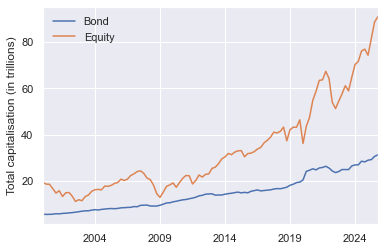

In [9]:
df[['bond', 'equity']].loc['2000':].plot();
plt.legend(['Bond', 'Equity'], frameon=False)
plt.ylabel('Total capitalisation (in trillions)');
#plt.savefig('bondequity.png');

We can also plot the empirical mandate.

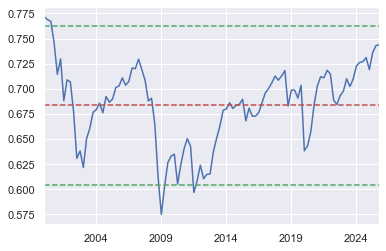

In [10]:
df['ratio'].loc['2000':].plot();
plt.axhline(df['ratio'].loc['2000':].mean(), color='r', ls='--');
plt.axhline(df['ratio'].loc['2000':].mean() - 1.96 * df['ratio'].loc['2000':].std(), color='g', ls='--');
plt.axhline(df['ratio'].loc['2000':].mean() + 1.96 * df['ratio'].loc['2000':].std(), color='g', ls='--');
#plt.savefig('empiricalmandate.png');

In [11]:
df['ratio'].loc['2000':].mean()

0.6835830369468846

## Backtesting

### Power mandate model

Fix $t \in \mathbb{N}$. Suppose the mandate-implied return function $f_t: (0, \infty) \rightarrow (0,\infty)$ satisfies

$$f_t = \mathrm{id} ^{\alpha^+}$$

where $\alpha^+ = \max(\alpha, 0)$. 

Let $i$ denote the $i$th sample $(i = 1,...., n)$, $y_i$ denote the stock price return (actually return + 1) and $x_i$ denote the bond price return (actually return + 1). Our **GOAL** is to find the **$\alpha$** to minimise our loss function

$$L(\alpha) = \sum_{i=1}^{n}(y_i - f_t(x_i))^2.$$

We use the 'minimize' function of the module 'scipy.optimize' to obtain the optimal parameter $\alpha^*$. We first define the loss function in the cell below, which later is used in the 'minimize' function.

In [12]:
def loss_function1(α, x, y_target):
    y_predicted = x ** α
    return sum((y_predicted - y_target)**2)

Now we approximate the optimal parameter $\alpha^*$. We use different rolling window length $l = 2, 3, 4$ years. This means in the notation above, we have $n = 4l$ (as we have quarterly data) and for every $n$ data, we compute one $\alpha$. We use the 'minimize' function from the 'scipy.optimize' module to find the optimal $\alpha^*$.

In [13]:
nlengths = [8, 12, 16]
colors = ['#ff7f0e','#2ca02c','#9467bd'] #orange, green, purple

In [14]:
columns_alpha = ['alpha_' + str(n) for n in nlengths]
columns_alpha_forecast = ['alpha_forecast_' + str(n) for n in nlengths]
columns_alpha_error = ['alpha_error_' + str(n) for n in nlengths]

plot_labels = (['$l = ' + str(int(n/4)) + '$' for n in nlengths] if all([(n/4).is_integer() for n in nlengths]) 
               else ['$l = ' + str(n/4) + '$' for n in nlengths])

for a in columns_alpha:
    df[a] = np.nan

In [15]:
for (n, a) in zip(nlengths, columns_alpha):
    for i in range(len(df) - n + 1):
        x = df.iloc[i:i+n]['bond_ret']
        y = df.iloc[i:i+n]['equity_ret']
        result = minimize(loss_function1, 1, args=(x, y)) #choose initial value as 1
        df[a].iloc[n - 1 + i] = np.maximum(result.x, 0)

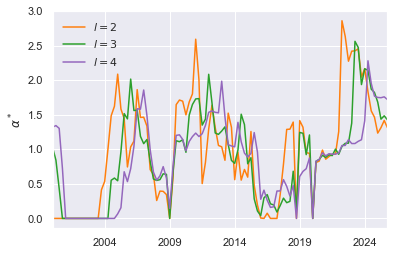

In [17]:
df[columns_alpha].loc['2000':].plot(color=colors)
plt.ylabel('$\\alpha^*$')
plt.legend(plot_labels, frameon=False);#as the data is seasonal
#plt.savefig('estimate3_in1.png',bbox_inches='tight')

Under different window lengths, we plot the model-implied stock value and the model prediction error. The model prediction error equals the difference between the equity value observation and the model-implied equity value.

In [18]:
for (f, a) in zip(columns_alpha_forecast, columns_alpha):
    df[f] = df['equity'].shift(1) * (df['bond_ret'] ** df[a].shift(1))

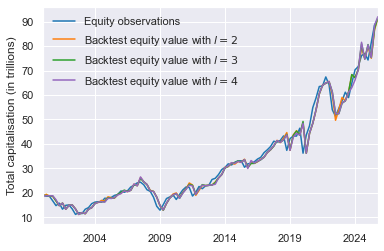

In [19]:
df[['equity'] + columns_alpha_forecast].loc['2000':].plot(color=['#1f77b4'] + colors)
plt.legend(['Equity observations'] + ['Backtest equity value with ' + p for p in plot_labels], frameon=False);
plt.ylabel('Total capitalisation (in trillions)');
#plt.savefig('backtest12.png',bbox_inches='tight');

In [20]:
df['error_equity_constant'] = df['equity'] - df['equity'].shift(1)

for (e, f) in zip(columns_alpha_error, columns_alpha_forecast):
    df[e] = df['equity'] - df[f]

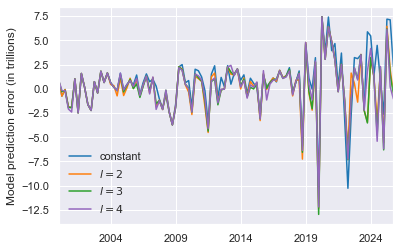

In [21]:
df[['error_equity_constant'] + columns_alpha_error].loc['2000':].plot(color=['#1f77b4'] + colors)

plt.legend(['constant'] + plot_labels, frameon=False)
plt.ylabel('Model prediction error (in trillions)')
#plt.savefig('backtesterrorpower.png',bbox_inches='tight');

The backtest above uses the data starting from $2000$. Since the starting date might potentially affect the outcomes of the backtest, we conduct following backtests starting from 1990, 1995, 2000, 2005 and 2010, respectively. 

In [22]:
startyears = ['1990', '1995', '2000', '2005']

In [23]:
df_error = pd.DataFrame()

for t in startyears:
    error_tmp = pd.DataFrame([(df['equity'] - df['equity'].shift(1)).loc[t:].abs().mean()])
    error_tmp = pd.concat([error_tmp, df[columns_alpha_error].loc[t:].abs().mean()])
    df_error = pd.concat([df_error, error_tmp], axis=1)

df_error.index = ['Constant error'] + plot_labels
df_error.columns = pd.MultiIndex.from_product([['Starting year'], startyears])
df_error.round(2)

Starting year                  
                        1990  1995  2000  2005
Constant error          1.64  1.87  2.06  2.28
$l = 2$                 1.49  1.69  1.86  2.03
$l = 3$                 1.48  1.69  1.85  2.03
$l = 4$                 1.49  1.70  1.86  2.03

In [24]:
error_style = (df_error.style.format('{:.2f}')
            .format_index("\\textbf{{{}}}", axis=1)
            .format_index("\\textbf{{\\boldmath{{{}}}}}", axis=0)
              )
print(error_style.to_latex(position="!ht", hrules=True, multicol_align = "l",
                           caption="Comparison of average absolute prediction errors (in trillions).", 
                           label = "alpha_error_compare", position_float = "centering"))

\begin{table}[!ht]
\centering
\caption{Comparison of average absolute prediction errors (in trillions).}
\label{alpha_error_compare}
\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{4}{l}{\textbf{Starting year}} \\
 & \textbf{1990} & \textbf{1995} & \textbf{2000} & \textbf{2005} \\
\midrule
\textbf{\boldmath{Constant error}} & 1.64 & 1.87 & 2.06 & 2.28 \\
\textbf{\boldmath{$l = 2$}} & 1.49 & 1.69 & 1.86 & 2.03 \\
\textbf{\boldmath{$l = 3$}} & 1.48 & 1.69 & 1.85 & 2.03 \\
\textbf{\boldmath{$l = 4$}} & 1.49 & 1.70 & 1.86 & 2.03 \\
\bottomrule
\end{tabular}
\end{table}



### Reverse model

Now we consider the model reversely (the dual model). Instead of using the bond data as model input, we now use the equity data as the model input. 

In [25]:
columns_alpha_tilde = ['alpha_tilde_' + str(n) for n in nlengths]
columns_alpha_tilde_forecast = ['forecast_alpha_tilde_' + str(n) for n in nlengths]
columns_alpha_tilde_error = ['error_alpha_tilde_' + str(n) for n in nlengths]

for a in columns_alpha_tilde:
    df[a] = np.nan

In [26]:
for (n, a) in zip(nlengths, columns_alpha_tilde):
    for i in range(len(df) - n + 1):
        x = df.iloc[i:i+n]['equity_ret']
        y = df.iloc[i:i+n]['bond_ret']
        result = minimize(loss_function1, 1, args=(x, y)) #choose initial value as 1
        df[a].iloc[n - 1 + i] = np.maximum(result.x, 0)

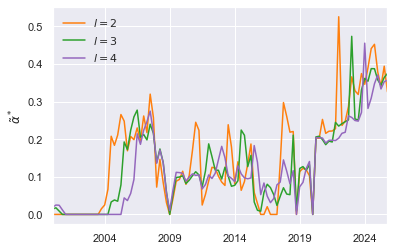

In [27]:
df[columns_alpha_tilde].loc['2000':].plot(color=colors)
plt.ylabel('$\\tilde{\\alpha}^*$')
plt.legend(plot_labels, frameon=False);

In [28]:
for (f, a) in zip(columns_alpha_tilde_forecast, columns_alpha_tilde):
    df[f] = df['bond'].shift(1) * (df['equity_ret'] ** df[a].shift(1))

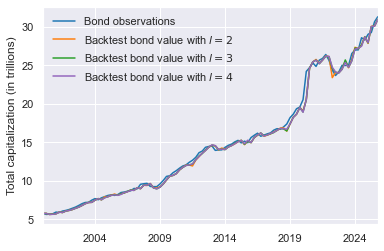

In [29]:
df[['bond'] + columns_alpha_tilde_forecast].loc['2000':].plot(color=['#1f77b4'] + colors)
plt.legend(['Bond observations'] + ['Backtest bond value with ' + p for p in plot_labels], frameon=False);
plt.ylabel('Total capitalization (in trillions)');

In [30]:
df['error_bond_constant'] = df['bond'] - df['bond'].shift(1)

for (e, f) in zip(columns_alpha_tilde_error, columns_alpha_tilde_forecast):
    df[e] = df['bond'] - df[f]

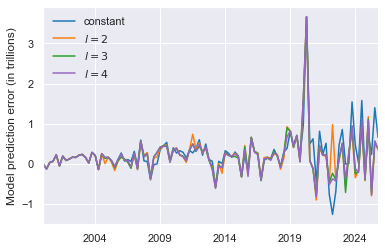

In [31]:
df[['error_bond_constant'] + columns_alpha_tilde_error].loc['2000':].plot(color=['#1f77b4'] + colors)

plt.legend(['constant'] + plot_labels, frameon=False)
plt.ylabel('Model prediction error (in trillions)');

In [32]:
df_error_tilde = pd.DataFrame()

for t in startyears:
    error_tmp = pd.DataFrame([(df['bond'] - df['bond'].shift(1)).loc[t:].abs().mean()])
    error_tmp = pd.concat([error_tmp, df[columns_alpha_tilde_error].loc[t:].abs().mean()])
    df_error_tilde = pd.concat([df_error_tilde, error_tmp], axis=1)

df_error_tilde.index = ['Constant error'] + plot_labels
df_error_tilde.columns = pd.MultiIndex.from_product([['Starting year'], startyears])

df_error_tilde.round(2)

Starting year                  
                        1990  1995  2000  2005
Constant error          0.28  0.31  0.36  0.41
$l = 2$                 0.27  0.30  0.34  0.39
$l = 3$                 0.26  0.29  0.33  0.38
$l = 4$                 0.26  0.29  0.33  0.38

Among the specifications, shorter rolling windows (in particular l = 2) consistently yield the strongest performance. Overall, the power mandate model delivers a clear improvement over a no-change benchmark in forecasting stock capitalisation. 

In the reverse specification, where stock returns are used to forecast bond returns via the dual mandate, the predictive performance is noticeably weaker. 

### Constant mandate model

Now suppose the mandate is a fixed constant $m_0 \in (0,1)$. Then the mandate-implied return function satisfies

$$f_t = \frac{m_0}{1-m_0} \frac{B_{t-1}}{P_{t-1}} \mathrm{id},$$

where $P$ denotes the stock value and $B$ denotes the bond value.


Let $i$ denote the $i$th sample $(i = 1,...., n)$, $y_i$ denote the stock price return  and $x_i$ denote the bond price return. Our **GOAL** is to find the **$\mu$** to minimise our loss function.
Choose the square error as the loss function: 

$$L(\mu) = \sum_{i=1}^{n}(y_i - \mu z_i)^2,$$

where $$\mu = \frac{m_0}{1-m_0}, \quad z_i = \frac{B_{i-1}}{P_{i-1}} x_i.$$

In this case, the loss function is given in the below cell.

In [55]:
def loss_function2(μ, x, y_target):
    y_predicted = μ * x 
    return sum((y_predicted - y_target)**2)

We first do preparation work. In the following cell, we compute $z_i$.

In [56]:
df['zi'] = (df['bond']/df['equity']).shift(1) * df['bond_ret']
df['zi_tilde'] = (df['equity']/df['bond']).shift(1) * df['equity_ret']

Now we estimate our parameter $m_0$.

In [57]:
columns_m = ['m_' + str(n) for n in nlengths]
columns_m_forecast = ['m_forecast_' + str(n) for n in nlengths]
columns_m_error = ['m_error_' + str(n) for n in nlengths]

for a in columns_m:
    df[a] = np.nan

In [58]:
for (n, a) in zip(nlengths, columns_m):
    for i in range(len(df) - n + 1):
        x = df.iloc[i:i+n]['zi']
        y = df.iloc[i:i+n]['equity_ret']
        result = minimize(loss_function2, 1, args=(x, y)) 
        df[a].iloc[n - 1 + i] = (result.x) / (1+ result.x)

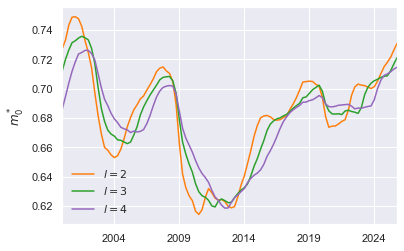

In [60]:
df[columns_m].loc['2000':].plot(color=colors)
plt.ylabel('$m_0^*$')
plt.legend(plot_labels, frameon=False);
#plt.savefig('m3_in1.png',bbox_inches='tight')

Under different window length, we plot the model-implied stock value and the model prediction error. 

In [61]:
for (f, a) in zip(columns_m_forecast, columns_m):
    df[f] = df['bond'] * (df[a].shift(1)/ (1 - df[a].shift(1)))

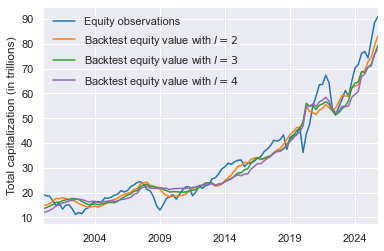

In [64]:
df[['equity'] + columns_m_forecast].loc['2000':].plot(color=['#1f77b4'] + colors)
plt.legend(['Equity observations'] + ['Backtest equity value with ' + p for p in plot_labels], frameon=False);
plt.ylabel('Total capitalization (in trillions)');
#plt.savefig('backtest3_in1.png',bbox_inches='tight')

In [65]:
for (e, f) in zip(columns_m_error, columns_m_forecast):
    df[e] = df['equity'] - df[f]

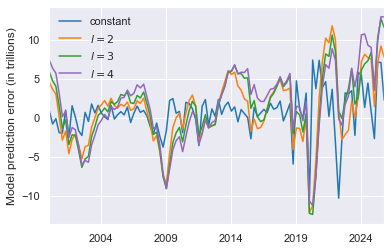

In [66]:
df[['error_equity_constant'] + columns_m_error].loc['2000':].plot(color=['#1f77b4'] + colors)

plt.legend(['constant'] + plot_labels, frameon=False)
plt.ylabel('Model prediction error (in trillions)')
#plt.savefig('backtesterror.png',bbox_inches='tight')

In [67]:
df_error_m = pd.DataFrame()

for t in startyears:
    error_tmp = pd.DataFrame([(df['equity'] - df['equity'].shift(1)).loc[t:].abs().mean()])
    error_tmp = pd.concat([error_tmp, df[columns_m_error].loc[t:].abs().mean()])
    df_error_m = pd.concat([df_error_m, error_tmp], axis=1)

df_error_m.index = ['Constant error'] + plot_labels
df_error_m.columns = pd.MultiIndex.from_product([['Starting year'], startyears])
df_error_m.round(2)

Starting year                  
                        1990  1995  2000  2005
Constant error          1.64  1.87  2.06  2.28
$l = 2$                 2.74  3.14  3.36  3.54
$l = 3$                 3.07  3.52  3.67  3.89
$l = 4$                 3.42  3.92  4.03  4.29

### Reverse model
Now we consider the model reversly. Instead of using the bond data as model input, we now use the equity data as the model input. 

In [68]:
columns_m_tilde = ['m_tilde_' + str(n) for n in nlengths]
columns_m_tilde_forecast = ['forecast_m_tilde_' + str(n) for n in nlengths]
columns_m_tilde_error = ['error_m_tilde_' + str(n) for n in nlengths]

for a in columns_m_tilde:
    df[a] = np.nan

In [69]:
for (n, a) in zip(nlengths, columns_m_tilde):
    for i in range(len(df) - n + 1):
        x = df.iloc[i:i+n]['zi_tilde']
        y = df.iloc[i:i+n]['bond_ret']
        result = minimize(loss_function2, 1, args=(x, y)) 
        df[a].iloc[n - 1 + i] = (result.x) / (1+ result.x)

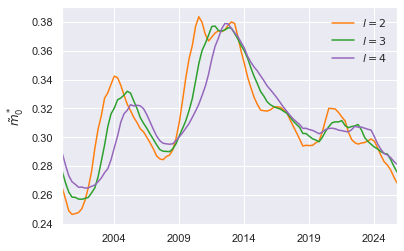

In [70]:
df[columns_m_tilde].loc['2000':].plot(color=colors)
plt.ylabel('$\\tilde{m}_0^*$')
plt.legend(plot_labels, frameon=False);
plt.savefig('mt3_in1.png',bbox_inches='tight')

Recall that the parameter $m_0$ is the proportion of the equity and $\tilde{m}_0$ is the proportion of the bond. Hence, technically speaking, the sum of these two parameters should be $1$. 

In [46]:
columns_empsum = ['m+m_tilde_' + str(n) for n in nlengths] #empirical summation of two parameters


for (s, a, b) in zip(columns_empsum, columns_m, columns_m_tilde):
    df[s] = df[a] + df[b]

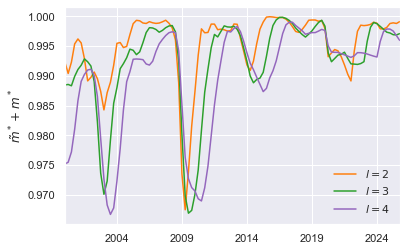

In [47]:
df[columns_empsum].loc['2000':].plot(color=colors)
plt.ylabel('$\\tilde{m}^* + m^*$')
plt.legend(plot_labels, frameon=False);
#plt.savefig('estimate_con_sum.png',bbox_inches='tight')

The sum of the estimated parameters remains close to one throughout most of the sample period, providing empirical support for the theoretical restriction. 

Larger deviations are observed around the global financial crisis, indicating that the model fit deteriorates during periods of extreme market conditions.

Again, under different window length, we plot the model-implied bond value and the model prediction error.

In [48]:
for (f, a) in zip(columns_m_tilde_forecast, columns_m_tilde):
    df[f] = df['equity'] * (df[a].shift(1)/ (1 - df[a].shift(1)))

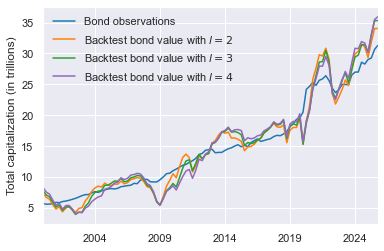

In [49]:
df[['bond'] + columns_m_tilde_forecast].loc['2000':].plot(color=['#1f77b4'] + colors)
plt.legend(['Bond observations'] + ['Backtest bond value with ' + p for p in plot_labels], frameon=False);
plt.ylabel('Total capitalization (in trillions)');

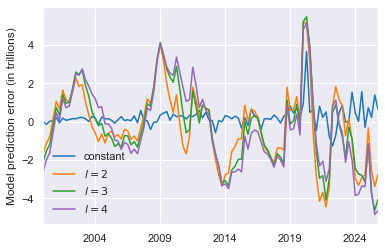

In [50]:
for (e, f) in zip(columns_m_tilde_error, columns_m_tilde_forecast):
    df[e] = df['bond'] - df[f]
    
df[['error_bond_constant'] + columns_m_tilde_error].loc['2000':].plot(color=['#1f77b4'] + colors)

plt.legend(['constant'] + plot_labels, frameon=False)
plt.ylabel('Model prediction error (in trillions)');

In [52]:
df_error_m_tilde = pd.DataFrame()

for t in startyears:
    error_tmp = pd.DataFrame([(df['bond'] - df['bond'].shift(1)).loc[t:].abs().mean()])
    error_tmp = pd.concat([error_tmp, df[columns_m_tilde_error].loc[t:].abs().mean()])
    df_error_m_tilde = pd.concat([df_error_m_tilde, error_tmp], axis=1)

df_error_m_tilde.index = ['Constant error'] + plot_labels
df_error_m_tilde.columns = pd.MultiIndex.from_product([['Starting year'], startyears])
df_error_m_tilde.round(2)

Starting year                  
                        1990  1995  2000  2005
Constant error          0.28  0.31  0.36  0.41
$l = 2$                 1.24  1.41  1.50  1.59
$l = 3$                 1.37  1.56  1.61  1.70
$l = 4$                 1.56  1.77  1.81  1.91

Overall, the constant mandate model performs relatively poorly in forecasting stock capitalisation. 
While it captures the general level of the data, it fails to adequately account for time variation in market conditions. In particular, its predictive performance is often comparable to, or worse than, a simple no-change benchmark, suggesting that a time-invariant allocation is too restrictive to capture the dynamics of equity capitalisation.